# 💳 Credit Card Customer Segmentation using Unsupervised Learning

## 📌 Project Overview
This project aims to segment credit card customers based on their financial and spending behaviour using unsupervised machine learning techniques. By identifying groups of customers with similar characteristics, banks can design targeted marketing campaigns, optimize credit limit decisions, improve customer retention, and provide personalized financial products.

## 🎯 Objectives
- Perform Exploratory Data Analysis (EDA) to understand customer behaviour.
- Engineer meaningful behavioural features from raw credit card usage data.
- Preprocess the data using missing value treatment, outlier handling, feature transformation, and scaling.
- Apply and compare K-Means, Agglomerative Hierarchical Clustering, and DBSCAN.
- Evaluate clustering performance using internal validation metrics.
- Interpret clusters and assign business personas for actionable banking insights.

---

# 📂 Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1 Load & Inspect the Dataset

In [2]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

# Model Saving
import joblib

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [ ]:
# Load Dataset
df = pd.read_csv("../data/CC GENERAL.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (8950, 18)


In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
# First 10 Rows
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [10]:
# Drop Customer ID
df.drop(columns="CUST_ID", inplace=True)

print("CUST_ID column dropped successfully.")

CUST_ID column dropped successfully.


In [11]:
# Missing Values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [12]:
# Missing Values Before Imputation
credit_limit_missing = df["CREDIT_LIMIT"].isnull().sum()
minimum_payment_missing = df["MINIMUM_PAYMENTS"].isnull().sum()

# Median Imputation
df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)

print(f"CREDIT_LIMIT values imputed : {credit_limit_missing}")
print(f"MINIMUM_PAYMENTS values imputed : {minimum_payment_missing}")

CREDIT_LIMIT values imputed : 1
MINIMUM_PAYMENTS values imputed : 313


In [13]:
# Duplicate Rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


## 1.2 Univariate Analysis

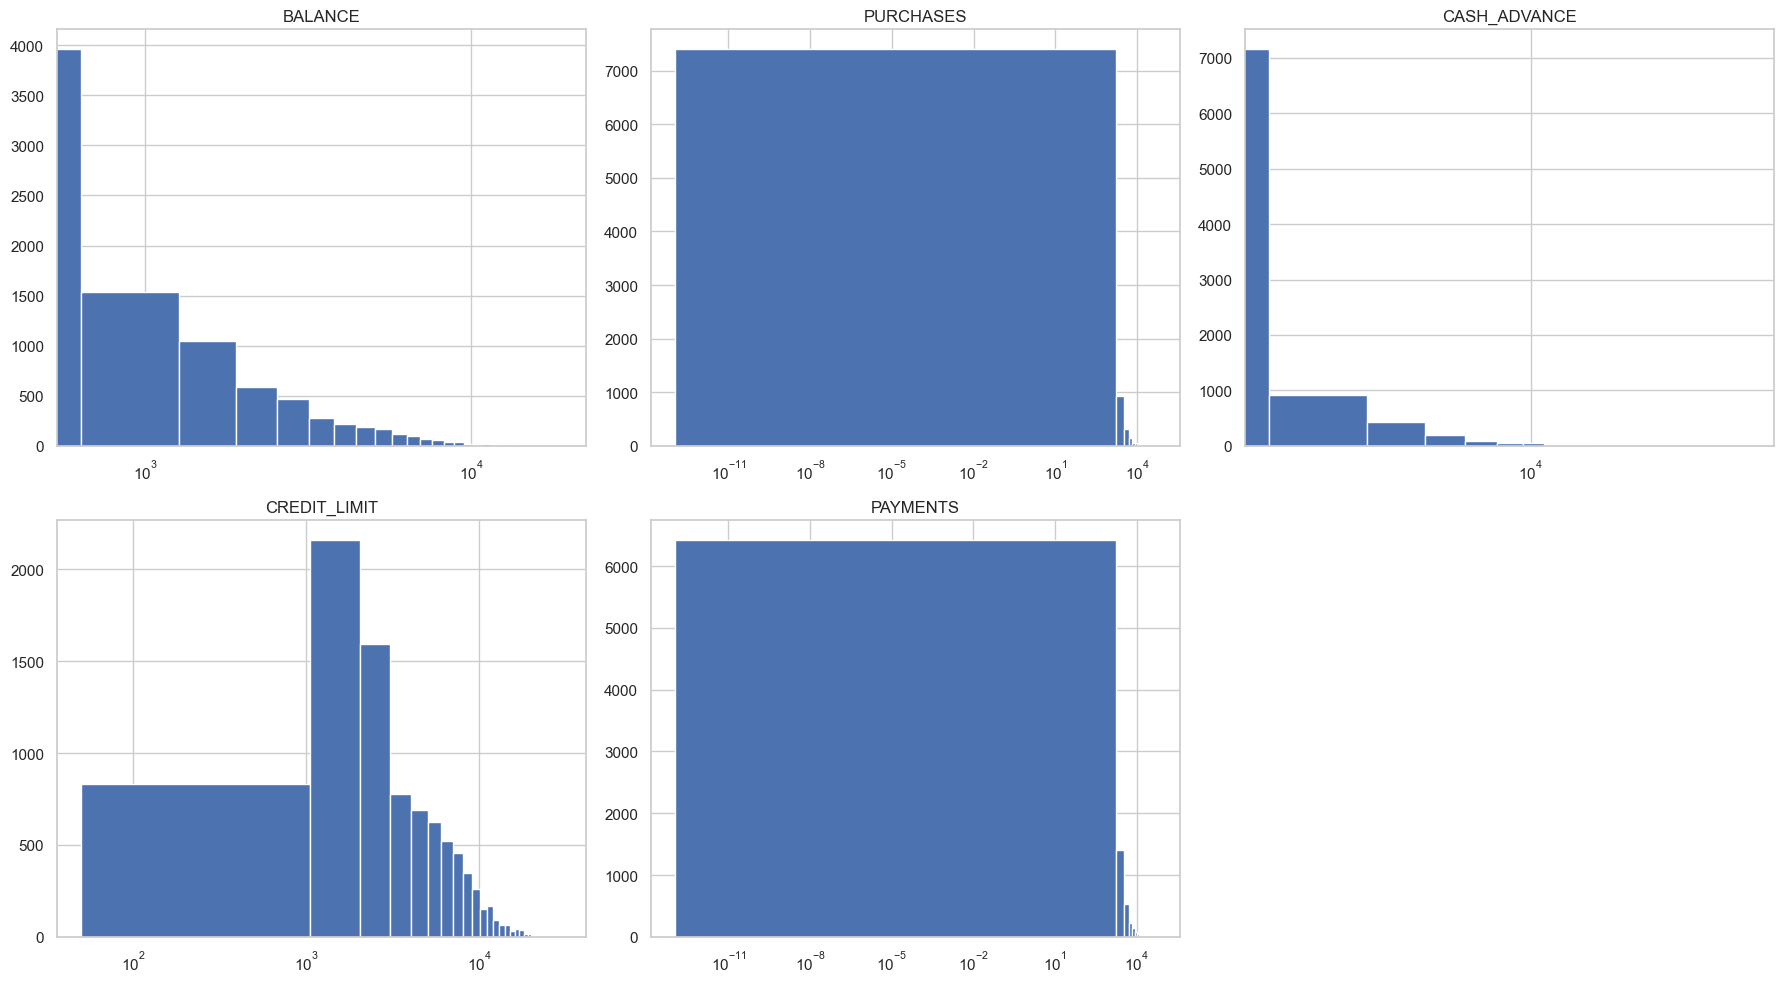

In [15]:
# Histograms (Log Scale)
columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xscale("log")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Interpretation

- Most monetary features are positively skewed, with a large number of customers having lower values and a few customers showing very high spending or balances.
- Applying a logarithmic x-axis improves the visibility of the distribution by reducing the impact of extreme values.

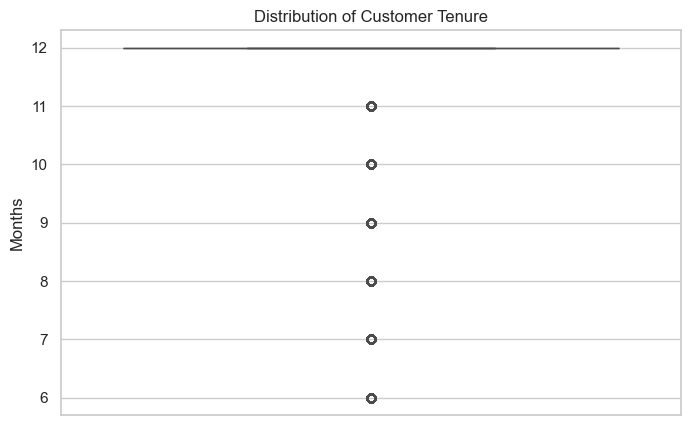

In [16]:
# TENURE Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(y=df["TENURE"])
plt.title("Distribution of Customer Tenure")
plt.ylabel("Months")
plt.show()

### Interpretation

- Most customers have maintained their credit cards for a relatively long period, while only a few have shorter tenures.
- The boxplot helps identify the spread of customer tenure and highlights any unusual observations.

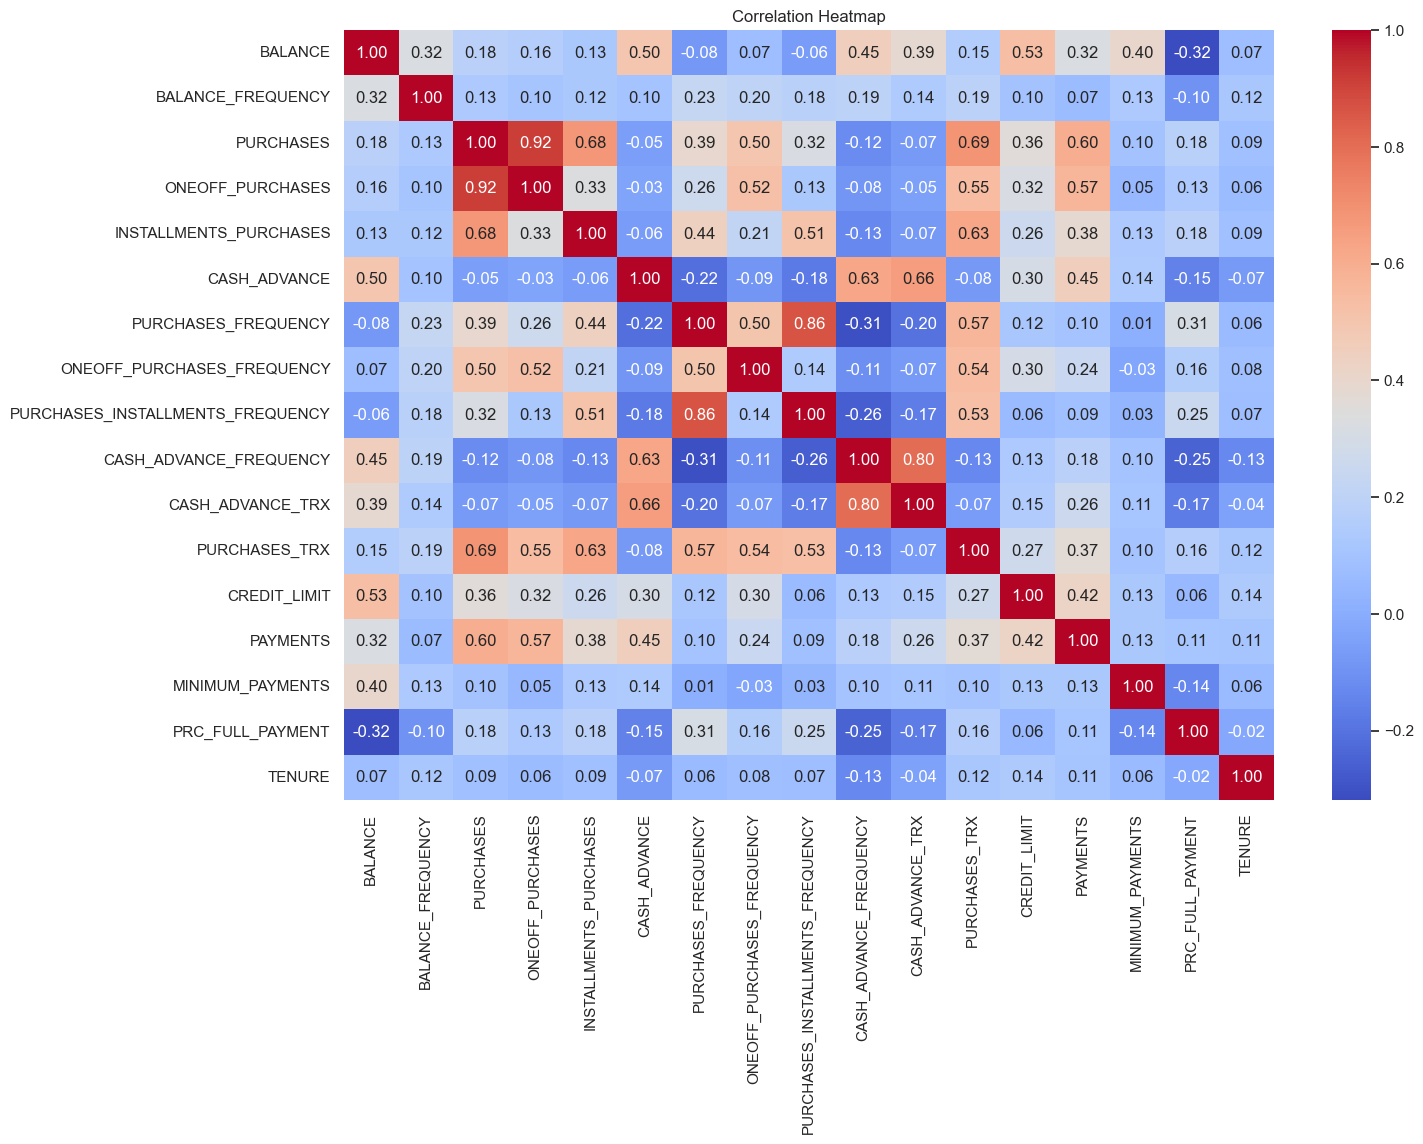

In [17]:
# Correlation Heatmap
plt.figure(figsize=(15,10))

corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- The heatmap shows the strength and direction of relationships between numerical features, helping identify highly correlated variables.
- Strong positive correlations indicate features that tend to increase together and may represent similar customer spending behaviours.

In [18]:
# Highly Correlated Features

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False))
high_corr = corr_pairs[abs(corr_pairs) >= 0.70]
print(high_corr)

PURCHASES               ONEOFF_PURCHASES                    0.916845
PURCHASES_FREQUENCY     PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX                    0.799561
dtype: float64


## 1.3 Customer-Level Analysis

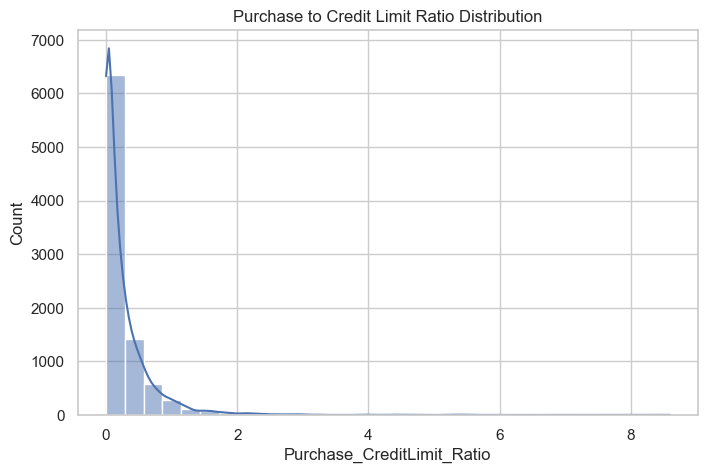

In [19]:
# Purchase to Credit Limit Ratio
df["Purchase_CreditLimit_Ratio"] = df["PURCHASES"] / df["CREDIT_LIMIT"]

plt.figure(figsize=(8,5))

sns.histplot(df["Purchase_CreditLimit_Ratio"], bins=30, kde=True)
plt.title("Purchase to Credit Limit Ratio Distribution")
plt.show()

### Interpretation

- Most customers have a low Purchase-to-Credit Limit Ratio, indicating that they utilize only a small portion of their available credit for purchases.
- A smaller group of customers shows higher utilization, suggesting more active spending behavior relative to their credit limit.


In [20]:
# Top 10 Customers by Cash Advance

top10_cash_advance = df.nlargest(10, "CASH_ADVANCE")[["CASH_ADVANCE", "PURCHASES"]]
top10_cash_advance

,CASH_ADVANCE,PURCHASES
2159,47137.21176,431.93
1059,29282.10915,3719.00
71,27296.48576,4523.27
7254,26268.69989,1750.66
7645,26194.04954,0.00
2454,23130.82106,0.00
883,22665.77850,0.00
6371,21943.84942,0.00
3806,20712.67008,4995.80
6455,20277.33112,1490.75


In [21]:
# Customers with No Purchases

no_purchase_percent = ((df["PURCHASES"] == 0).mean()) * 100

print(f"Customers with No Purchases: {no_purchase_percent:.2f}%")

Customers with No Purchases: 22.84%


In [22]:
# Pareto Analysis (80-20 Rule)

purchase_sorted = df.sort_values(by="PURCHASES", ascending=False)
cumulative_purchase = purchase_sorted["PURCHASES"].cumsum()

target = purchase_sorted["PURCHASES"].sum() * 0.80
customers_needed = (cumulative_purchase <= target).sum() + 1
percentage_customers = (customers_needed / len(df)) * 100

print(f"{percentage_customers:.2f}% of customers contribute approximately 80% of total purchases.")

26.21% of customers contribute approximately 80% of total purchases.


---

# 🔧 Step 2: Feature Engineering & Preprocessing

## 2.1 Engineer Behavioural Features

In [23]:
# Feature Engineering

df["Monthly_Avg_Purchase"] = df["PURCHASES"] / df["TENURE"]

df["Monthly_Avg_Cash_Advance"] = df["CASH_ADVANCE"] / df["TENURE"]

df["Limit_Usage"] = np.where(df["CREDIT_LIMIT"] == 0, 0, df["BALANCE"] / df["CREDIT_LIMIT"])

df["Payment_to_Minpayment_Ratio"] = (df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1))

In [24]:
# Display Newly Engineered Features

engineered_features = ["Monthly_Avg_Purchase", "Monthly_Avg_Cash_Advance", "Limit_Usage", "Payment_to_Minpayment_Ratio"]
df[engineered_features].head()

,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,7.950000,0.000000,0.040901,1.436214
1,0.000000,536.912124,0.457495,3.822677
2,64.430833,0.000000,0.332687,0.990103
3,124.916667,17.149001,0.222223,0.000000
4,1.333333,0.000000,0.681429,2.759800


In [27]:
# Statistical Summary

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Avg_Purchase,8950.0,86.175173,180.508787,0.0,3.399375,31.936667,97.228333,4086.630833
Monthly_Avg_Cash_Advance,8950.0,88.977984,193.136115,0.0,0.000000,0.000000,99.085196,3928.100980
Limit_Usage,8950.0,0.388884,0.389722,0.0,0.041494,0.302720,0.717571,15.909951
Payment_to_Minpayment_Ratio,8950.0,6.390555,31.995344,0.0,0.910572,2.016643,6.013980,1863.850036


In [28]:
# Skewness of Engineered Features

df[engineered_features].skew().sort_values(ascending=False)

Payment_to_Minpayment_Ratio    36.902249
Monthly_Avg_Purchase            8.004530
Limit_Usage                     7.416991
Monthly_Avg_Cash_Advance        4.944361
dtype: float64

## 2.2 Handle Outliers

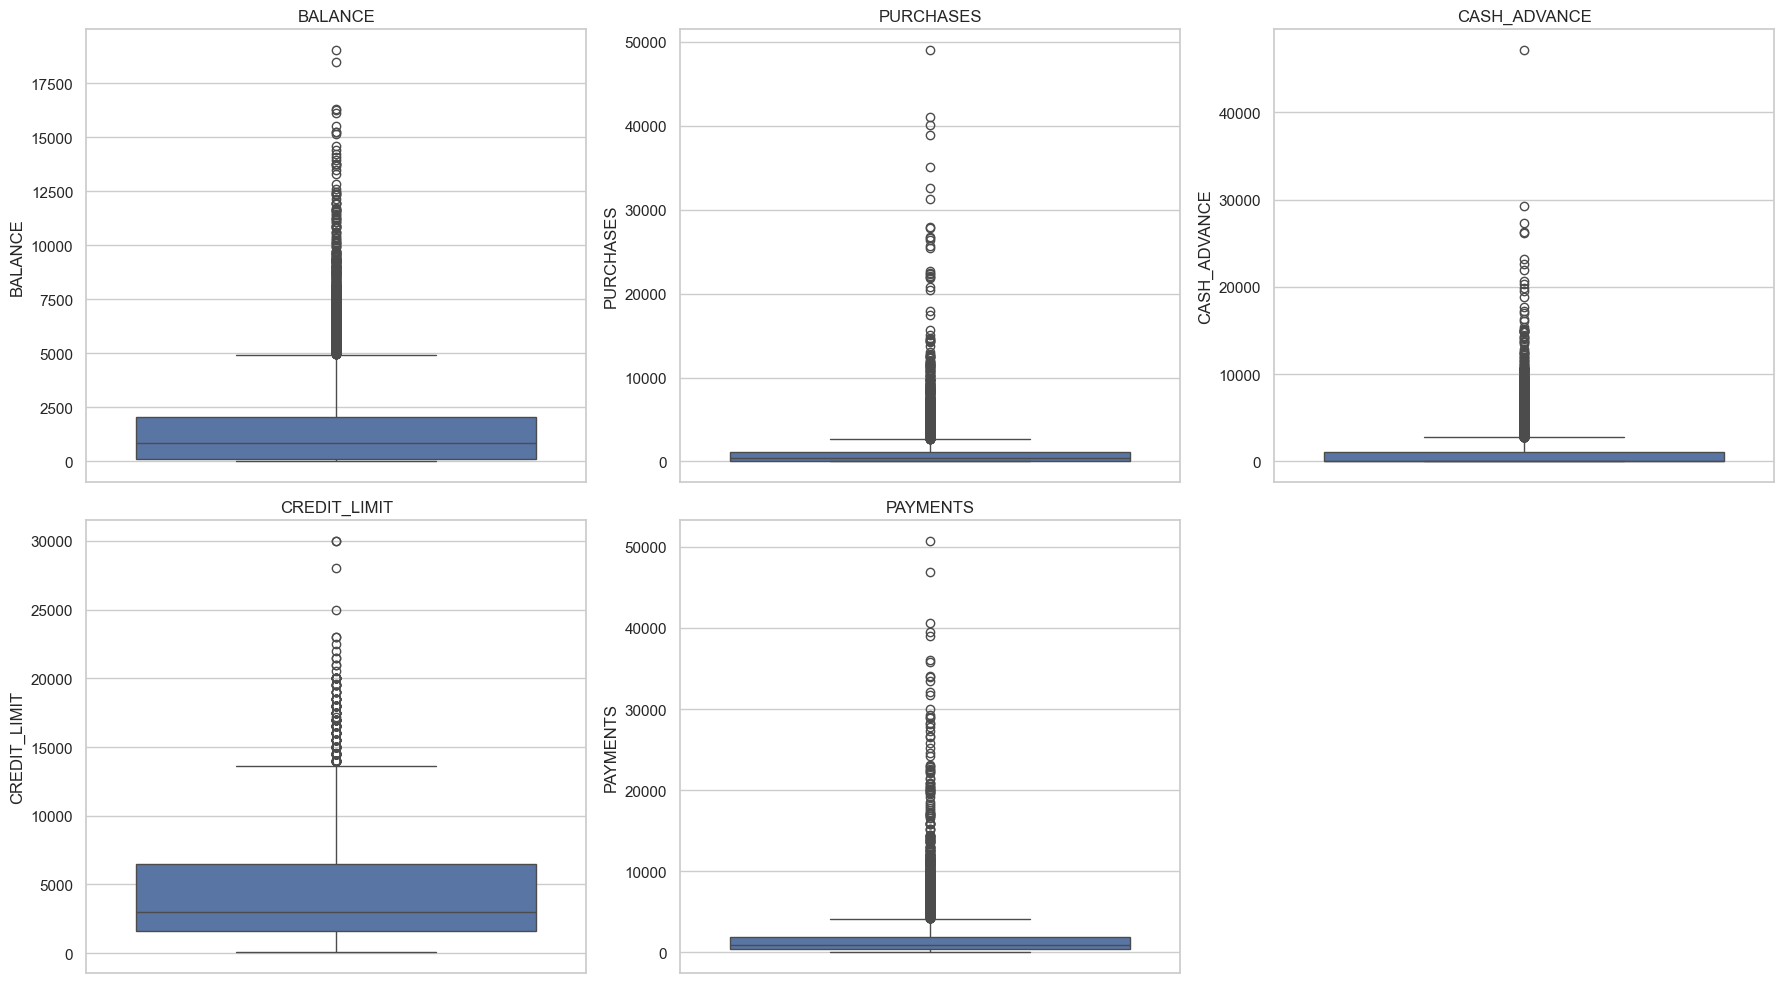

In [29]:
# Boxplots Before Outlier Treatment

columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i,col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

- The boxplots reveal the presence of several extreme values, especially in monetary features such as BALANCE, PURCHASES and CASH_ADVANCE.
- These outliers can influence clustering results, making outlier treatment an important preprocessing step.

In [30]:
# IQR Winsorization (Upper Cap)

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + (3 * IQR)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers capped successfully.")

Outliers capped successfully.


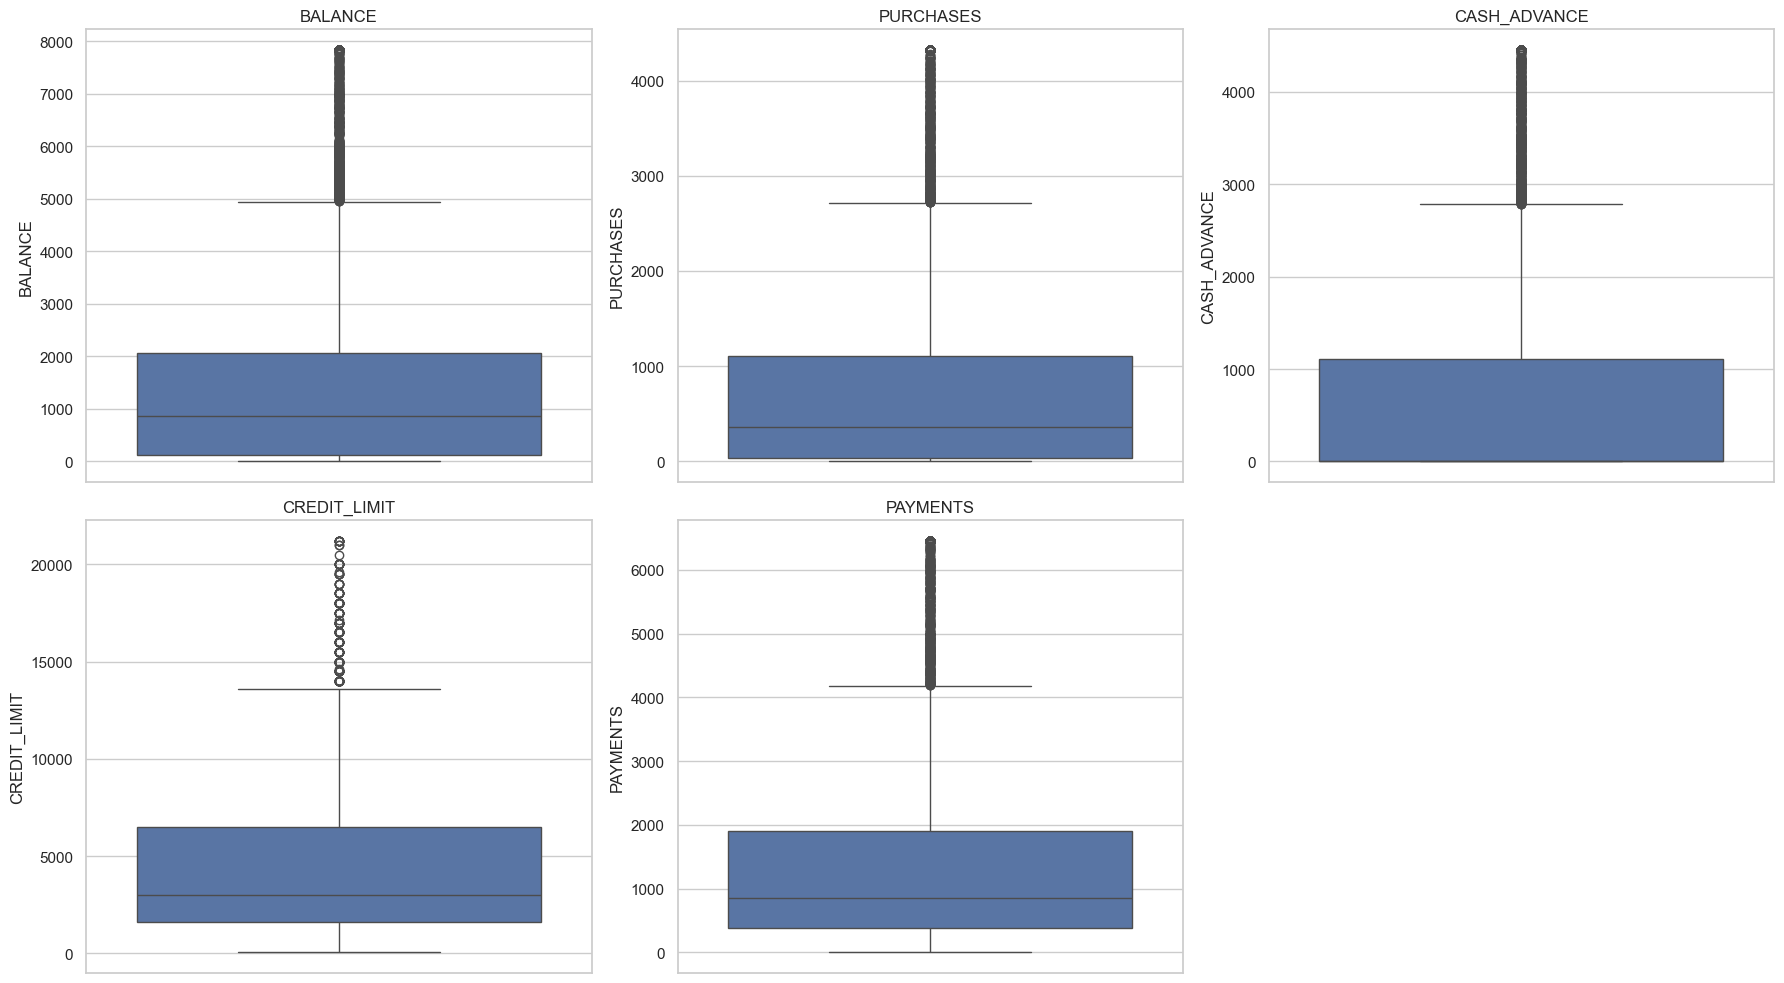

In [31]:
# Boxplots After Outlier Treatment

fig, axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i,col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

- Extreme outliers have been capped using the IQR method while preserving all customer records.
- The distributions are now less influenced by unusually large values, making them more suitable for clustering.

## 2.3 Transform Skewed Features

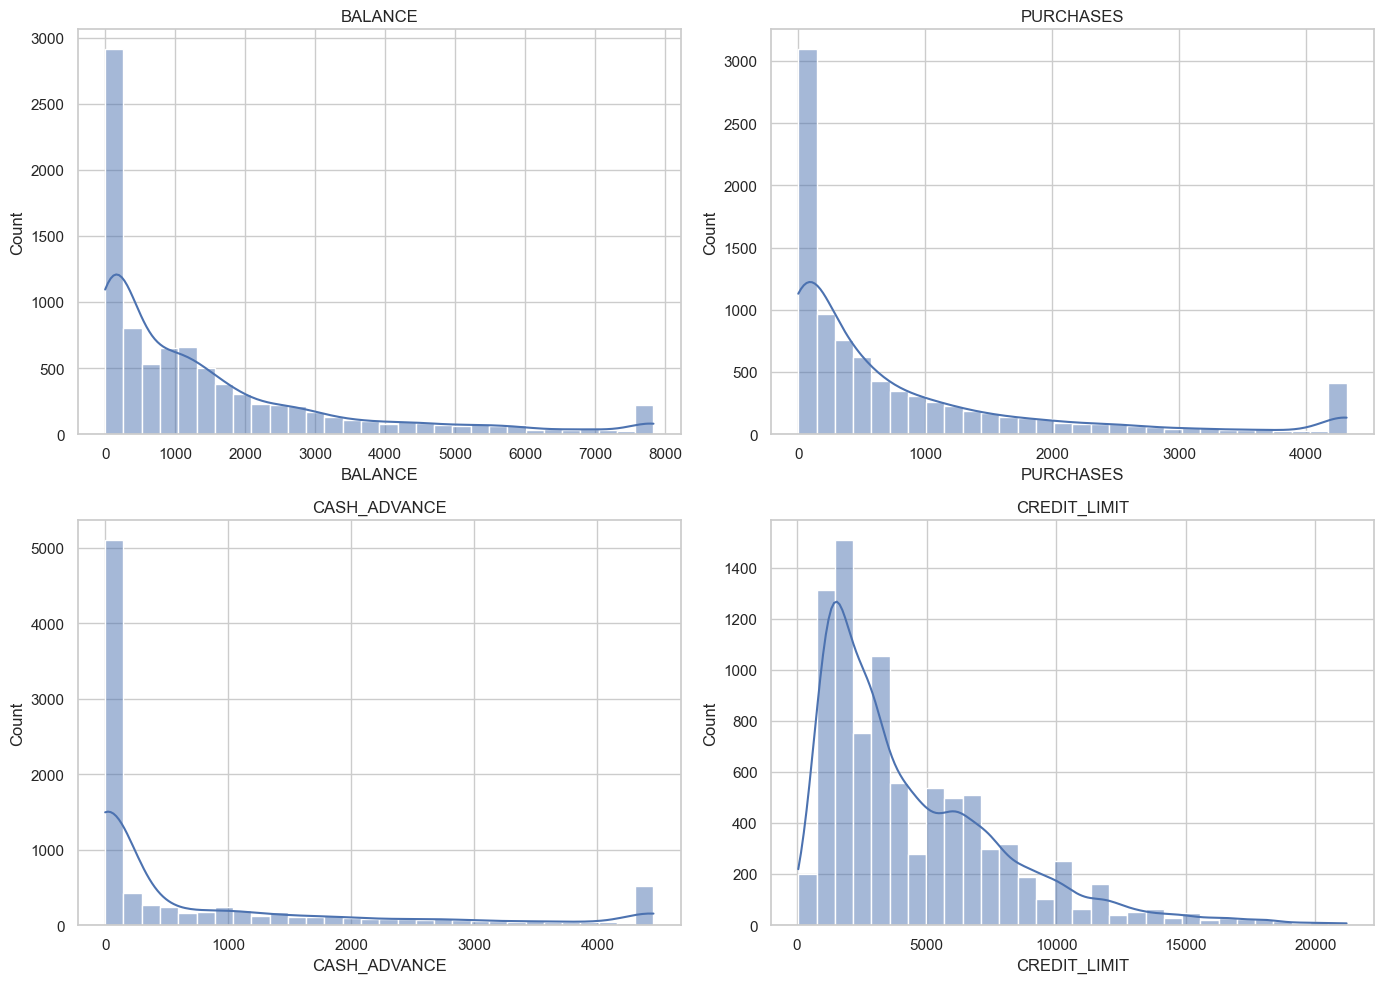

In [32]:
# Histograms Before Transformation

transform_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]

fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

for i,col in enumerate(transform_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

###  Interpretation

- Most monetary variables are positively skewed, with many low-value customers and a few extremely high-value customers.
- Applying a transformation can make these distributions more balanced for clustering.

In [33]:
# Log Transformation

for col in transform_cols:
    df[col] = np.log1p(df[col])
    
print("Log Transformation Applied.")

Log Transformation Applied.


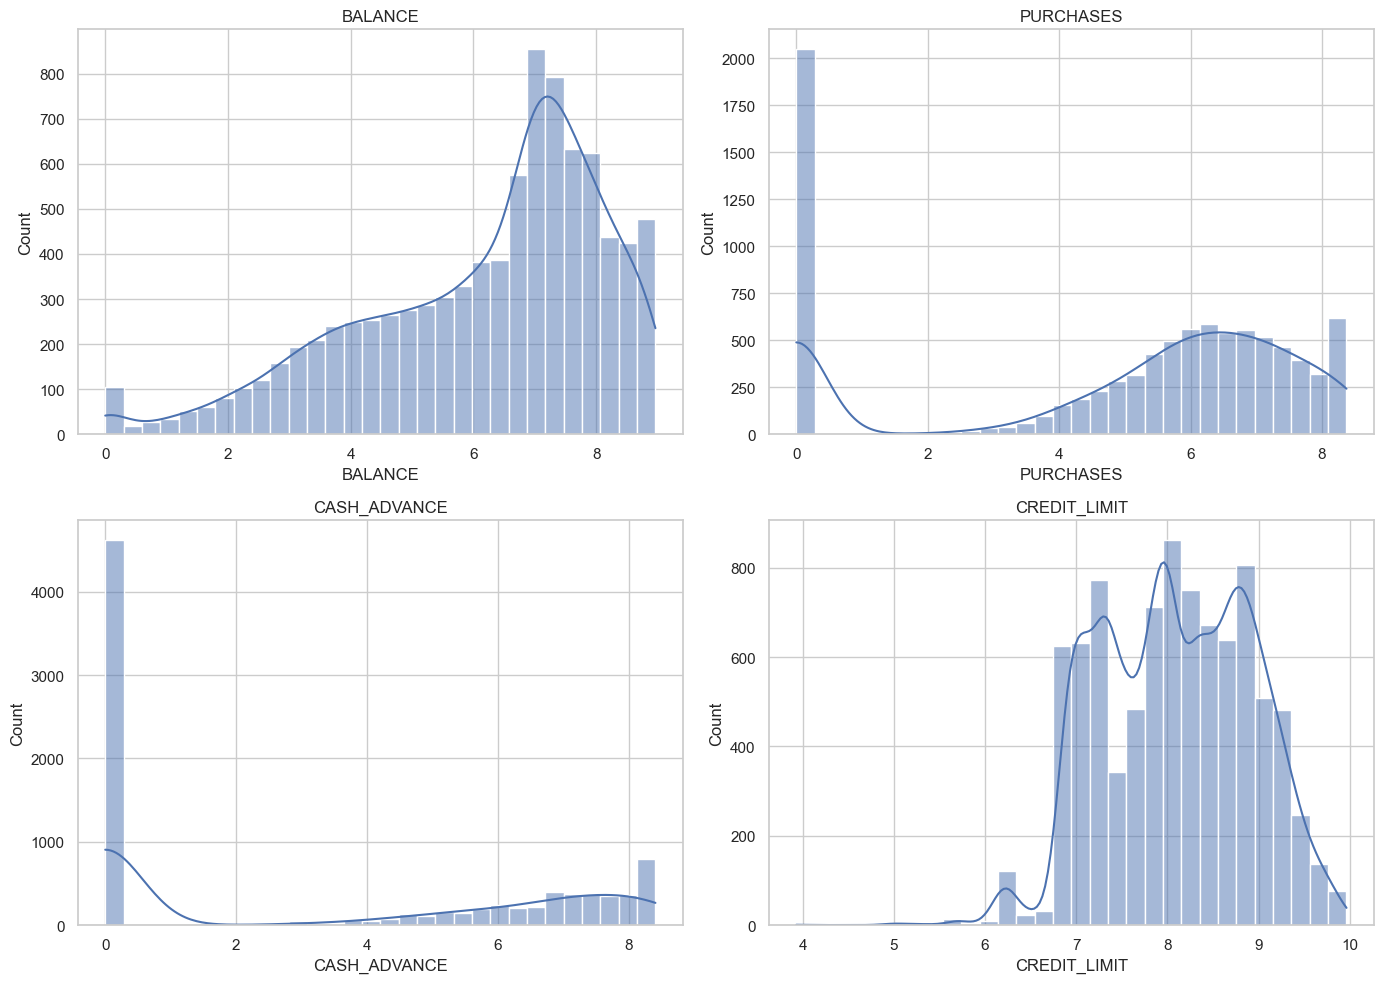

In [34]:
# Histograms After Transformation

fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

for i,col in enumerate(transform_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Interpretation

- After applying the log transformation, the distributions appear more symmetrical and less right-skewed.
- This transformation helps clustering algorithms perform more effectively by reducing the influence of large values.

## 2.4 Scale the Features

In [35]:
# Feature Scaling

scaler = StandardScaler()
cc_scaled = scaler.fit_transform(df)
cc_scaled = pd.DataFrame(cc_scaled, columns=df.columns)
cc_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Purchase_CreditLimit_Ratio,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,-1.207143,-0.249434,-0.107336,-0.356934,-0.349079,-0.933764,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-1.447653,-0.782590,-0.302400,-0.525551,0.36068,-0.382946,-0.433384,-0.460727,-0.892951,-0.154854
1,0.954731,0.134325,-1.689286,-0.356934,-0.454576,1.447518,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.926693,1.580002,0.097500,0.234227,0.36068,-0.601434,-0.477428,2.319396,0.176063,-0.080262
2,0.830361,0.518084,0.614049,0.108889,-0.454576,-0.933764,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,1.010901,-0.528077,-0.093293,-0.525551,0.36068,-0.365336,-0.120468,-0.460727,-0.144206,-0.168798
3,0.629302,-1.016953,0.843084,0.546189,-0.454576,0.577324,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,1.010901,-0.904802,-0.228307,-0.525551,0.36068,-0.143694,0.214636,-0.371929,-0.427665,-0.199745
4,0.274639,0.518084,-0.708221,-0.347294,-0.454576,-0.933764,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-1.225295,-0.494001,-0.257266,-0.525551,0.36068,-0.570897,-0.470041,-0.460727,0.750693,-0.113484


In [37]:
# Mean and Standard Deviation

scaled_summary = pd.DataFrame({"Mean": cc_scaled.mean(), "Std Dev": cc_scaled.std()})
print(scaled_summary)

                                          Mean   Std Dev
BALANCE                           1.397268e-16  1.000056
BALANCE_FREQUENCY                 2.286439e-16  1.000056
PURCHASES                        -1.206732e-16  1.000056
ONEOFF_PURCHASES                  3.175610e-17  1.000056
INSTALLMENTS_PURCHASES            2.540488e-17  1.000056
CASH_ADVANCE                      8.256586e-17  1.000056
PURCHASES_FREQUENCY              -1.841854e-16  1.000056
ONEOFF_PURCHASES_FREQUENCY       -8.891708e-17  1.000056
PURCHASES_INSTALLMENTS_FREQUENCY  4.604634e-17  1.000056
CASH_ADVANCE_FREQUENCY            5.557317e-17  1.000056
CASH_ADVANCE_TRX                 -2.540488e-17  1.000056
PURCHASES_TRX                    -2.540488e-17  1.000056
CREDIT_LIMIT                      5.843122e-16  1.000056
PAYMENTS                          1.397268e-16  1.000056
MINIMUM_PAYMENTS                  5.716098e-17  1.000056
PRC_FULL_PAYMENT                  0.000000e+00  1.000056
TENURE                         

In [38]:
# PCA (90-95% Variance)

pca = PCA(n_components=0.95, random_state=42)
cc_pca = pca.fit_transform(cc_scaled)

print("Original Features :", cc_scaled.shape[1])
print("Principal Components Retained :", pca.n_components_)
print("Explained Variance :", round(pca.explained_variance_ratio_.sum()*100,2), "%")

Original Features : 22
Principal Components Retained : 15
Explained Variance : 95.28 %


---

# 🔵 Step 3: K-Means Clustering

## 3.1 Elbow Method — Find Optimal k

In [39]:
# Elbow Method & Silhouette Score

inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:    
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(cc_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append( silhouette_score(cc_scaled, labels))

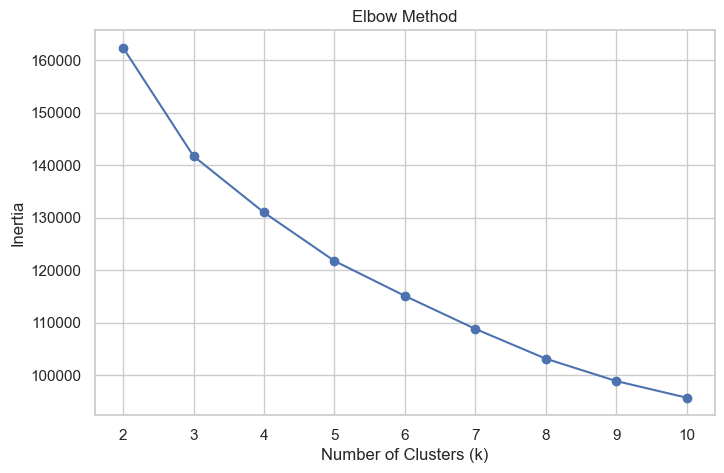

In [40]:
# Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.grid(True)
plt.show()

### Interpretation

- The elbow curve helps identify the point where adding more clusters provides only marginal improvement.
- The bend in the curve indicates a suitable number of clusters for K-Means.

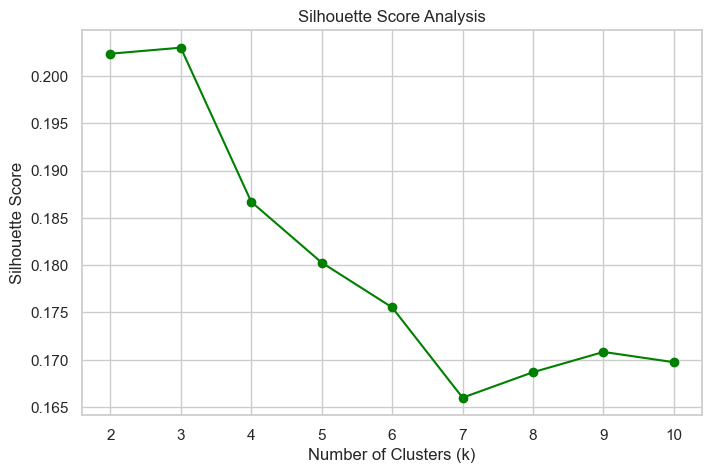

In [41]:
# Silhouette Score

plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker="o", color="green")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.xticks(k_values)
plt.grid(True)
plt.show()

###  Interpretation

- Higher Silhouette Scores indicate better-separated and more compact clusters.
- The optimal value of k generally corresponds to the highest silhouette score while also aligning with the elbow point.

In [42]:
# Display Evaluation Scores

evaluation = pd.DataFrame({"k": list(k_values), "Inertia": inertia, "Silhouette Score": silhouette_scores})
evaluation

,k,Inertia,Silhouette Score
0,2,162416.145086,0.202340
1,3,141730.462071,0.202979
2,4,130983.007063,0.186693
3,5,121744.749900,0.180270
4,6,115077.159864,0.175537
5,7,108783.146951,0.165998
6,8,103101.820767,0.168689
7,9,98835.022523,0.170830
8,10,95665.905039,0.169742


In [43]:
# Best k based on Silhouette Score

best_k = evaluation.loc[evaluation["Silhouette Score"].idxmax(), "k"]
print(f"Optimal k based on Silhouette Score: {best_k}")

Optimal k based on Silhouette Score: 3


###  Interpretation

- Based on the Elbow Method and Silhouette Score, **k = 3** provides a good balance between cluster compactness and separation.
- Therefore, **k = 3** is selected as the optimal number of clusters for building the final K-Means model.

## 3.2 Train Final K-Means Model

In [44]:
# Final K-Means Model

kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=20, max_iter=500, random_state=42)

df["KMeans_Cluster"] = kmeans.fit_predict(cc_scaled)
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    3319
1    4340
2    1291
Name: count, dtype: int64

## 3.3 Visualise K-Means Clusters

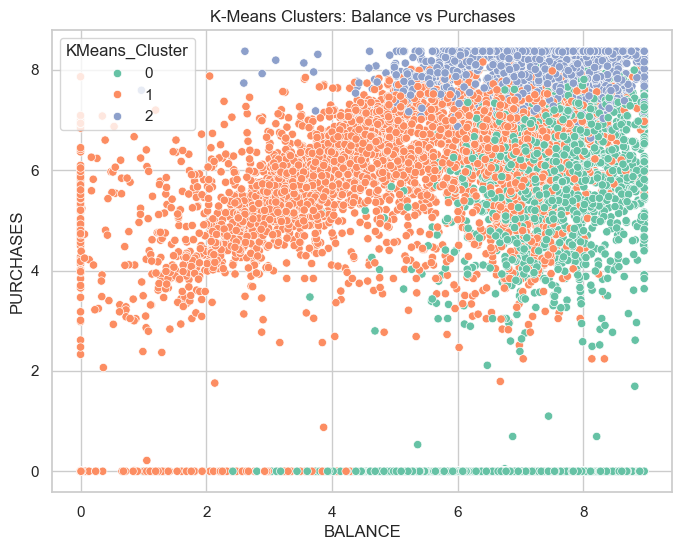

In [45]:
# BALANCE vs PURCHASES

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="BALANCE", y="PURCHASES", hue="KMeans_Cluster", palette="Set2")
plt.title("K-Means Clusters: Balance vs Purchases")
plt.show()

###  Interpretation

- The scatter plot shows how customers are grouped based on their balance and purchase behaviour.
- Well-separated groups indicate that K-Means has identified distinct customer segments.

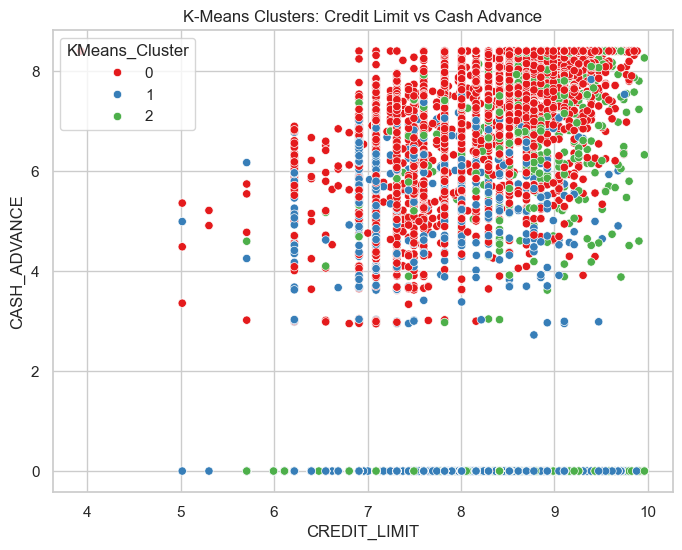

In [46]:
# CREDIT_LIMIT vs CASH_ADVANCE

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="CREDIT_LIMIT", y="CASH_ADVANCE", hue="KMeans_Cluster", palette="Set1")
plt.title("K-Means Clusters: Credit Limit vs Cash Advance")
plt.show()

### Interpretation

- Customers with similar credit limits and cash advance usage are grouped into the same cluster.
- The visualization highlights different spending and borrowing behaviours across customer segments.

In [ ]:
# 3D Scatter Plot

fig = px.scatter_3d(df,
                    x="BALANCE",
                    y="PURCHASES",
                    z="CASH_ADVANCE",
                    color=df["KMeans_Cluster"].astype(str),
                    title="3D K-Means Cluster Visualization",
                    opacity=0.75,
                    height=700,
                    width=1000)

fig.update_traces(marker=dict(size=3))
fig.update_layout(scene=dict(xaxis_title="Balance", 
                             yaxis_title="Purchases",
                             zaxis_title="Cash Advance", 
                             aspectmode="cube"),
                  legend_title="Cluster",
                  margin=dict(l=0, r=0, b=0, t=50))
fig.show()

###  Interpretation

- The 3D visualization provides a clearer view of cluster separation across three important financial features.
- Distinct groupings suggest meaningful customer segmentation based on spending and cash advance behaviour.

## 3.4 Profile the K-Means Clusters

In [59]:
# Cluster Profile

cluster_profile = (df.groupby("KMeans_Cluster")[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "TENURE"]].mean().sort_values(by="CREDIT_LIMIT", ascending=False))

cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
2,7.112782,7.980654,2.338497,8.644157,3369.571162,11.886135
0,7.413695,2.374155,6.984008,8.119245,1619.572495,11.357939
1,4.911251,5.870868,0.757702,7.912414,840.163311,11.529493


### 📌 Business Personas

| Cluster | Business Persona | Justification |
|:-------:|--------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **2** | **Premium Transactors** | Customers with the highest purchases, credit limits, and payments while maintaining relatively low cash advance usage. They actively use their cards and repay responsibly. |
| **0** | **Cash-Advance Reliant** | Customers with the highest cash advance usage and high outstanding balances, indicating greater reliance on cash withdrawals than regular purchases. |
| **1** | **Moderate Card Users** | Customers with lower balances, lower credit limits, and moderate purchases with minimal cash advance usage, representing average day-to-day card users. |

In [57]:
display(cluster_profile)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
2,7.112782,7.980654,2.338497,8.644157,3369.571162,11.886135
0,7.413695,2.374155,6.984008,8.119245,1619.572495,11.357939
1,4.911251,5.870868,0.757702,7.912414,840.163311,11.529493
